In [4]:
"""
analysis.ipynb — Analysis of the ablation results (runs locally, no GPU needed).

Loads the trained embeddings + all experiment summaries, then explores:
consolidated results, t-SNE, per-genre/nationality accuracy, qualitative
top-10, and failure analysis.
"""

import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# ADJUST THESE THREE PATHS to match your laptop.
# ----------------------------------------------------------------------

# Folder where you downloaded the cluster outputs (contains the dated subfolders
# like 2026-06-02_multiseed, 2026-06-01_caption_comparison, etc.)
OUTPUTS_DIR = Path(r"C:\Users\ebteda\Desktop\thesis\outputs")

# The canonical artist list (name, genre, nationality, ...)
ARTIST_CSV = Path(r"C:\Users\ebteda\Desktop\thesis\data\artists\artists_mio_3000_updated.csv")

# The union triplets file (used to reconstruct the test split)
TRIPLETS_FILE = Path(r"C:\Users\ebteda\Desktop\thesis\data\triplets\triplets_ids_music_spot_updated.csv")

# ----------------------------------------------------------------------

# Names of the experiment folders (adjust the dates if yours differ)
FOLDER_MULTISEED = OUTPUTS_DIR / "2026-06-02_multiseed"
FOLDER_SOURCE    = OUTPUTS_DIR / "2026-06-02_source_comparison"
FOLDER_CAPTION   = OUTPUTS_DIR / "2026-06-01_caption_comparison"
FOLDER_HPARAMS   = OUTPUTS_DIR / "2026-06-01_hyperparams"

print("Checking that the key paths exist:\n")
for label, p in [
    ("Outputs dir", OUTPUTS_DIR),
    ("Artist CSV", ARTIST_CSV),
    ("Triplets file", TRIPLETS_FILE),
    ("Multiseed folder", FOLDER_MULTISEED),
    ("Source folder", FOLDER_SOURCE),
    ("Caption folder", FOLDER_CAPTION),
    ("Hyperparams folder", FOLDER_HPARAMS),
]:
    status = "OK" if p.exists() else "MISSING"
    print(f"  [{status:7s}] {label}: {p}")

Checking that the key paths exist:

  [OK     ] Outputs dir: C:\Users\ebteda\Desktop\thesis\outputs
  [OK     ] Artist CSV: C:\Users\ebteda\Desktop\thesis\data\artists\artists_mio_3000_updated.csv
  [OK     ] Triplets file: C:\Users\ebteda\Desktop\thesis\data\triplets\triplets_ids_music_spot_updated.csv
  [OK     ] Multiseed folder: C:\Users\ebteda\Desktop\thesis\outputs\2026-06-02_multiseed
  [OK     ] Source folder: C:\Users\ebteda\Desktop\thesis\outputs\2026-06-02_source_comparison
  [OK     ] Caption folder: C:\Users\ebteda\Desktop\thesis\outputs\2026-06-01_caption_comparison
  [OK     ] Hyperparams folder: C:\Users\ebteda\Desktop\thesis\outputs\2026-06-01_hyperparams


In [5]:
# Load the artist table: maps UUID -> name, genre, nationality

artists_df = pd.read_csv(ARTIST_CSV)
artists_df = artists_df.drop(columns=[c for c in artists_df.columns if c.startswith("Unnamed")])
artists_df = artists_df.set_index("musicbrainz_id")

print("Artist table shape:", artists_df.shape)
print("Columns:", list(artists_df.columns))

# Convenience lookups
name_to_uuid = dict(zip(artists_df["name"], artists_df.index))

def uuid_name(u):
    return artists_df.loc[u, "name"] if u in artists_df.index else "(unknown)"

def uuid_genre(u):
    return artists_df.loc[u, "genre"] if u in artists_df.index else "(unknown)"

def uuid_nationality(u):
    return artists_df.loc[u, "nationality"] if u in artists_df.index else "(unknown)"

print("\nMetadata lookups ready.")

Artist table shape: (3008, 6)
Columns: ['name', 'link_spotify', 'link_allmusic', 'instagram_spotify', 'nationality', 'genre']

Metadata lookups ready.


In [6]:
# Pull the summary table from each of the 4 experiments into one place,
# so the whole experimental campaign is visible at a glance.

def safe_read(path):
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"  Could not read {path}: {e}")
        return None

print("=" * 70)
print("EXPERIMENT 1 — Modality ablations (multi-seed, with error bars)")
print("=" * 70)
multiseed = safe_read(FOLDER_MULTISEED / "summary_aggregated.csv")
if multiseed is not None:
    cols = ["label", "test_acc_mean", "test_acc_std", "gap_mean", "recall_at_10_mean"]
    print(multiseed[cols].sort_values("test_acc_mean", ascending=False).to_string(index=False))

print("\n" + "=" * 70)
print("EXPERIMENT 2 — Similarity source comparison")
print("=" * 70)
source = safe_read(FOLDER_SOURCE / "summary_aggregated.csv")
if source is not None:
    cols = ["source", "label", "test_acc_mean", "test_acc_std", "recall_at_10_mean"]
    print(source[cols].sort_values(["label", "source"]).to_string(index=False))

print("\n" + "=" * 70)
print("EXPERIMENT 3 — Caption method comparison (English vs multilingual)")
print("=" * 70)
caption = safe_read(FOLDER_CAPTION / "summary_aggregated.csv")
if caption is not None:
    cols = ["caption_type", "label", "test_acc_mean", "test_acc_std"]
    print(caption[cols].sort_values(["label", "caption_type"]).to_string(index=False))

print("\n" + "=" * 70)
print("EXPERIMENT 4 — Hyperparameter tuning (3-modality model)")
print("=" * 70)
hparams = safe_read(FOLDER_HPARAMS / "summary_aggregated.csv")
if hparams is not None:
    cols = ["hp_config", "margin", "dropout", "batch_size", "test_acc_mean", "test_acc_std"]
    print(hparams[cols].sort_values("test_acc_mean", ascending=False).to_string(index=False))

EXPERIMENT 1 — Modality ablations (multi-seed, with error bars)
                               label  test_acc_mean  test_acc_std  gap_mean  recall_at_10_mean
                     Image + caption       0.982124      0.001205  0.547054           0.288286
                          Image only       0.975815      0.000821  0.549612           0.252513
                        Caption only       0.974632      0.003063  0.525314           0.272178
                          Audio only       0.974106      0.002907  0.539157           0.239708
Image + caption + audio (full 3-mod)       0.972266      0.001778  0.523968           0.231064
                       Image + audio       0.966088      0.004444  0.511165           0.190249
                     Caption + audio       0.937040      0.010450  0.456912           0.118364

EXPERIMENT 2 — Similarity source comparison
  source                           label  test_acc_mean  test_acc_std  recall_at_10_mean
allmusic         Image + caption (2-mod)  

In [7]:
# Load the per-artist 256-dim embeddings for the three configurations we'll
# analyze most closely. We use the seed_42 run as representative.

def load_embeddings(path):
    with open(path, "rb") as f:
        emb = pickle.load(f)
    # Normalize shape to (256,) and dtype float32
    return {k: np.asarray(v).squeeze().astype(np.float32) for k, v in emb.items()}

EMB_PATHS = {
    "2-mod (image+caption)": FOLDER_MULTISEED / "04_image_caption" / "seed_42" / "embeddings_256.pkl",
    "3-mod (full)":          FOLDER_MULTISEED / "07_full_3mod"     / "seed_42" / "embeddings_256.pkl",
    "audio-only":            FOLDER_MULTISEED / "01_audio_only"    / "seed_42" / "embeddings_256.pkl",
}

embeddings = {}
for label, path in EMB_PATHS.items():
    if path.exists():
        embeddings[label] = load_embeddings(path)
        n = len(embeddings[label])
        shape = embeddings[label][next(iter(embeddings[label]))].shape
        print(f"  Loaded {label}: {n} artists, shape {shape}")
    else:
        print(f"  MISSING: {label} -> {path}")

print("\nEmbedding sets loaded:", list(embeddings.keys()))

  Loaded 2-mod (image+caption): 2895 artists, shape (256,)
  Loaded 3-mod (full): 2895 artists, shape (256,)
  Loaded audio-only: 2895 artists, shape (256,)

Embedding sets loaded: ['2-mod (image+caption)', '3-mod (full)', 'audio-only']


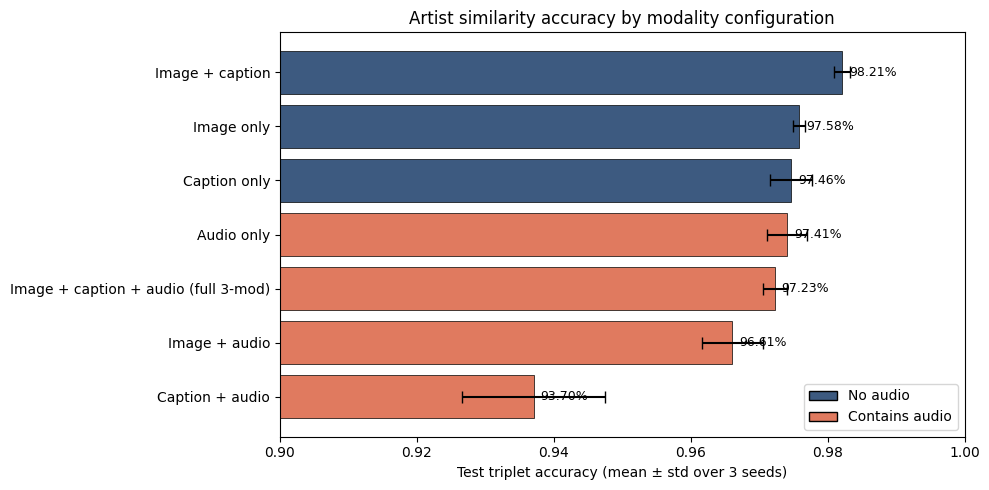

Saved to C:\Users\ebteda\Desktop\thesis\analysis_figures\modality_accuracy_barchart.png


In [8]:
# Summary bar chart: test accuracy of all 7 modality configurations, with error bars.
# Configs containing audio are colored differently to make the story visual.

import matplotlib.pyplot as plt

# Folder to save figures for the thesis
FIGURES_DIR = OUTPUTS_DIR.parent / "analysis_figures"
FIGURES_DIR.mkdir(exist_ok=True)

# Reload the multiseed summary so this cell is self-contained
ms = pd.read_csv(FOLDER_MULTISEED / "summary_aggregated.csv")
ms = ms.sort_values("test_acc_mean", ascending=True).reset_index(drop=True)  # ascending for horizontal bars

# Color: audio-containing configs in one color, non-audio in another
def has_audio(label):
    return "audio" in label.lower()

colors = ["#e07a5f" if has_audio(l) else "#3d5a80" for l in ms["label"]]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    ms["label"],
    ms["test_acc_mean"],
    xerr=ms["test_acc_std"],
    color=colors,
    edgecolor="black",
    linewidth=0.5,
    capsize=4,
)

# Annotate each bar with its value
for i, (mean, std) in enumerate(zip(ms["test_acc_mean"], ms["test_acc_std"])):
    ax.text(mean + 0.001, i, f"{mean*100:.2f}%", va="center", fontsize=9)

ax.set_xlim(0.90, 1.00)   # zoomed to make differences visible (note: not 0-based)
ax.set_xlabel("Test triplet accuracy (mean ± std over 3 seeds)")
ax.set_title("Artist similarity accuracy by modality configuration")

# Legend
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor="#3d5a80", edgecolor="black", label="No audio"),
    Patch(facecolor="#e07a5f", edgecolor="black", label="Contains audio"),
]
ax.legend(handles=legend_elems, loc="lower right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "modality_accuracy_barchart.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved to {FIGURES_DIR / 'modality_accuracy_barchart.png'}")

Common artists across all embedding sets: 2895
Top 8 genres used for coloring: ['rock', 'nan', 'pop', 'metal', 'hip hop', 'jazz', 'indie', 'country']
Running t-SNE for: 2-mod (image+caption) ...
Running t-SNE for: 3-mod (full) ...
Running t-SNE for: audio-only ...


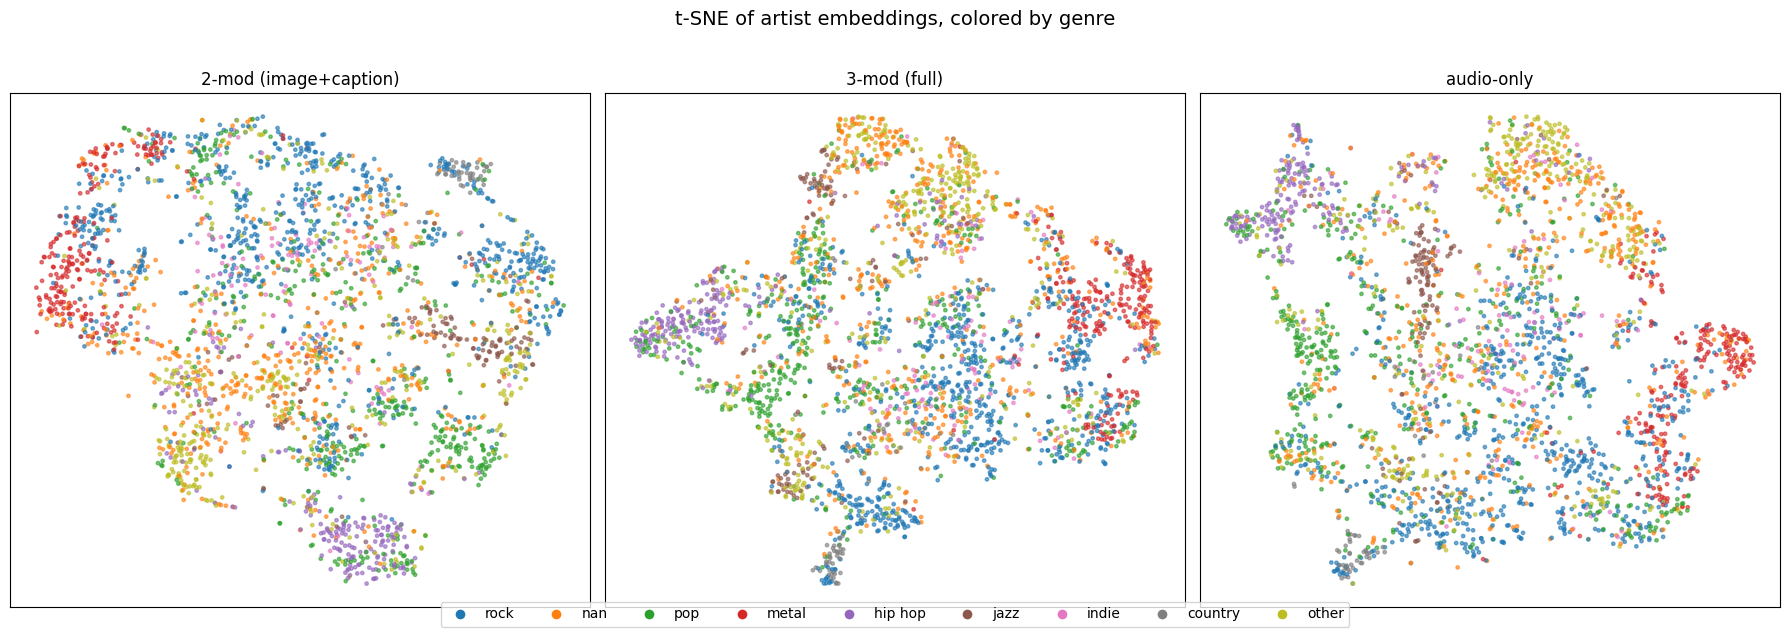

Saved to C:\Users\ebteda\Desktop\thesis\analysis_figures\tsne_embeddings_by_genre.png


In [9]:
# t-SNE: project each embedding set to 2D, color by genre.
# Side-by-side panels let us see whether audio blurs the genre clusters.
# This takes a few minutes (t-SNE on 2,895 points, run 3 times).

from sklearn.manifold import TSNE

# Common artist order across all three embedding sets
common_uuids = sorted(set(embeddings["2-mod (image+caption)"].keys())
                      & set(embeddings["3-mod (full)"].keys())
                      & set(embeddings["audio-only"].keys()))
print(f"Common artists across all embedding sets: {len(common_uuids)}")

# Genre per artist; pick the most common genres to color, lump the rest as "other"
genres = [str(uuid_genre(u)) for u in common_uuids]
genre_counts = pd.Series(genres).value_counts()
TOP_N_GENRES = 8
top_genres = list(genre_counts.head(TOP_N_GENRES).index)
print(f"Top {TOP_N_GENRES} genres used for coloring: {top_genres}")

def genre_label(g):
    return g if g in top_genres else "other"

point_genres = [genre_label(g) for g in genres]

# Consistent color map across all panels
all_categories = top_genres + ["other"]
cmap = plt.get_cmap("tab10")
genre_to_color = {g: cmap(i % 10) for i, g in enumerate(all_categories)}
point_colors = [genre_to_color[g] for g in point_genres]

# Compute t-SNE for each embedding set
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, emb) in zip(axes, embeddings.items()):
    print(f"Running t-SNE for: {label} ...")
    M = np.stack([emb[u] for u in common_uuids]).astype(np.float32)
    tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=42)
    coords = tsne.fit_transform(M)
    ax.scatter(coords[:, 0], coords[:, 1], c=point_colors, s=6, alpha=0.6)
    ax.set_title(label)
    ax.set_xticks([]); ax.set_yticks([])

# Shared legend
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=genre_to_color[g],
           markersize=8, label=g)
    for g in all_categories
]
fig.legend(handles=legend_elems, loc="lower center", ncol=len(all_categories), bbox_to_anchor=(0.5, -0.02))

plt.suptitle("t-SNE of artist embeddings, colored by genre", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "tsne_embeddings_by_genre.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved to {FIGURES_DIR / 'tsne_embeddings_by_genre.png'}")

Pearson correlation (image+caption sim vs audio sim): 0.6839
Spearman correlation: 0.6100


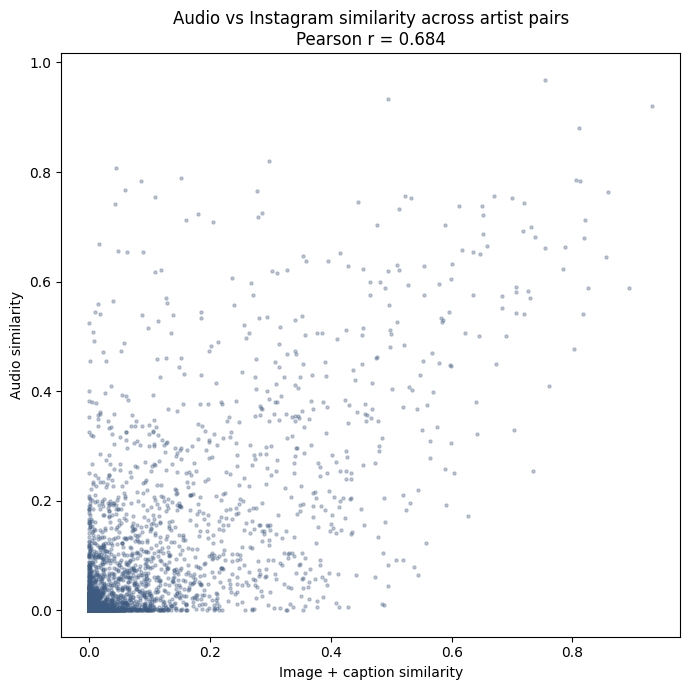


Saved to C:\Users\ebteda\Desktop\thesis\analysis_figures\audio_vs_instagram_similarity.png


In [10]:
# Core argument: audio adds little because image+caption already captures the
# same similarity structure. We measure this directly: across many random
# artist pairs, how correlated is audio-only similarity with image+caption
# similarity? High correlation = audio is largely redundant.

def build_normalized_matrix(emb, uuids):
    M = np.stack([emb[u] for u in uuids]).astype(np.float32)
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return M / norms

M_2mod  = build_normalized_matrix(embeddings["2-mod (image+caption)"], common_uuids)
M_audio = build_normalized_matrix(embeddings["audio-only"], common_uuids)

# Sample random pairs
rng = np.random.default_rng(42)
N_PAIRS = 10000
ia = rng.integers(0, len(common_uuids), size=N_PAIRS)
ib = rng.integers(0, len(common_uuids), size=N_PAIRS)
keep = ia != ib
ia, ib = ia[keep], ib[keep]

# Cosine similarity per pair in each space (dot product of normalized vectors)
sim_2mod  = np.sum(M_2mod[ia]  * M_2mod[ib],  axis=1)
sim_audio = np.sum(M_audio[ia] * M_audio[ib], axis=1)

# Pearson (numpy, no dependency)
pearson = np.corrcoef(sim_2mod, sim_audio)[0, 1]
print(f"Pearson correlation (image+caption sim vs audio sim): {pearson:.4f}")

# Spearman (scipy if available)
try:
    from scipy.stats import spearmanr
    spearman, _ = spearmanr(sim_2mod, sim_audio)
    print(f"Spearman correlation: {spearman:.4f}")
except ImportError:
    print("(scipy not installed; skipping Spearman. pip install scipy to add it.)")

# Scatter plot (subsample for readability)
sub = rng.choice(len(sim_2mod), size=min(3000, len(sim_2mod)), replace=False)
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(sim_2mod[sub], sim_audio[sub], s=5, alpha=0.3, color="#3d5a80")
ax.set_xlabel("Image + caption similarity")
ax.set_ylabel("Audio similarity")
ax.set_title(f"Audio vs Instagram similarity across artist pairs\nPearson r = {pearson:.3f}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "audio_vs_instagram_similarity.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSaved to {FIGURES_DIR / 'audio_vs_instagram_similarity.png'}")

In [11]:
# Reconstruct the EXACT test triplets the training used (same filter, same
# seed-42 shuffle, same 70/20/10 split). Needed for per-group accuracy and
# failure analysis.

triplets_df = pd.read_csv(TRIPLETS_FILE)

usable_set = set(common_uuids)
mask = (
    triplets_df["anchor"].isin(usable_set)
    & triplets_df["positive"].isin(usable_set)
    & triplets_df["negative"].isin(usable_set)
)
triplets_df = triplets_df[mask].reset_index(drop=True)
triplets_df = triplets_df.sample(frac=1, random_state=42).reset_index(drop=True)

n_total = len(triplets_df)
n_train = int(0.70 * n_total)
n_val   = int(0.20 * n_total)

test_df = triplets_df.iloc[n_train + n_val:].reset_index(drop=True)
test_triplets = list(zip(test_df["anchor"], test_df["positive"], test_df["negative"]))
print(f"Reconstructed test triplets: {len(test_triplets)}")

# Per-embedding normalized lookup for fast cosine
def make_lookup(emb):
    out = {}
    for u, v in emb.items():
        n = np.linalg.norm(v)
        out[u] = v / n if n > 0 else v
    return out

lookups = {label: make_lookup(emb) for label, emb in embeddings.items()}

def triplet_correct(lookup, a, p, n):
    """True if anchor is closer to positive than to negative (cosine)."""
    sim_ap = float(lookup[a] @ lookup[p])
    sim_an = float(lookup[a] @ lookup[n])
    return sim_ap > sim_an   # higher cosine = closer

print("Lookups ready for:", list(lookups.keys()))

Reconstructed test triplets: 2536
Lookups ready for: ['2-mod (image+caption)', '3-mod (full)', 'audio-only']


Per-genre test accuracy: 2-mod vs 3-mod (audio_effect = 3mod - 2mod)
(Negative audio_effect = audio HURTS that genre)

  group  n_2mod  accuracy_2mod  accuracy_3mod  audio_effect
   rock    1022       0.982387       0.975538     -0.006849
    pop     487       0.977413       0.960986     -0.016427
  metal     221       0.981900       0.981900      0.000000
    nan     207       0.985507       0.961353     -0.024155
hip hop     133       0.977444       0.984962      0.007519
  indie      77       0.987013       0.961039     -0.025974
   jazz      71       0.985915       0.943662     -0.042254
country      61       0.983607       0.983607      0.000000
classic      35       0.971429       0.942857     -0.028571
   soul      30       1.000000       0.966667     -0.033333
 techno      28       1.000000       0.928571     -0.071429
   punk      21       0.904762       0.952381      0.047619
  dance      20       1.000000       1.000000      0.000000


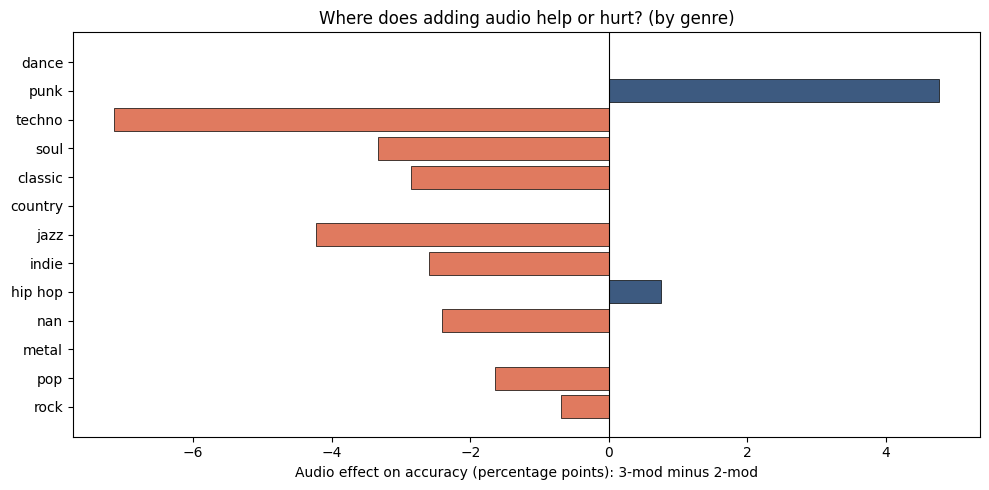

In [12]:
# For each config, compute test-triplet accuracy grouped by the ANCHOR's genre.
# Shows where audio helps vs hurts across genres.

from collections import defaultdict

def per_group_accuracy(lookup, group_func, min_count=20):
    correct = defaultdict(int)
    total   = defaultdict(int)
    for a, p, n in test_triplets:
        g = group_func(a)
        total[g] += 1
        if triplet_correct(lookup, a, p, n):
            correct[g] += 1
    rows = []
    for g in total:
        if total[g] >= min_count:   # skip groups too small to trust
            rows.append({"group": g, "accuracy": correct[g] / total[g], "n": total[g]})
    return pd.DataFrame(rows).sort_values("n", ascending=False)

# Compute per-genre accuracy for the two key configs
genre_2mod = per_group_accuracy(lookups["2-mod (image+caption)"], lambda u: str(uuid_genre(u)))
genre_3mod = per_group_accuracy(lookups["3-mod (full)"],          lambda u: str(uuid_genre(u)))

# Merge for side-by-side comparison
genre_cmp = genre_2mod.merge(genre_3mod, on="group", suffixes=("_2mod", "_3mod"))
genre_cmp["audio_effect"] = genre_cmp["accuracy_3mod"] - genre_cmp["accuracy_2mod"]
genre_cmp = genre_cmp.sort_values("n_2mod", ascending=False)

print("Per-genre test accuracy: 2-mod vs 3-mod (audio_effect = 3mod - 2mod)")
print("(Negative audio_effect = audio HURTS that genre)\n")
print(genre_cmp[["group", "n_2mod", "accuracy_2mod", "accuracy_3mod", "audio_effect"]].to_string(index=False))

# Bar chart of the audio effect per genre
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#3d5a80" if e >= 0 else "#e07a5f" for e in genre_cmp["audio_effect"]]
ax.barh(genre_cmp["group"], genre_cmp["audio_effect"] * 100, color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Audio effect on accuracy (percentage points): 3-mod minus 2-mod")
ax.set_title("Where does adding audio help or hurt? (by genre)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "audio_effect_by_genre.png", dpi=150, bbox_inches="tight")
plt.show()

Per-nationality test accuracy: 2-mod vs 3-mod

group  n_2mod  accuracy_2mod  accuracy_3mod  audio_effect
   us    1918       0.982273       0.974974     -0.007299
   de     268       0.985075       0.977612     -0.007463
   gb     211       0.976303       0.933649     -0.042654
   fr      56       0.964286       0.910714     -0.053571
   es      42       0.976190       0.952381     -0.023810
   it      41       1.000000       1.000000      0.000000


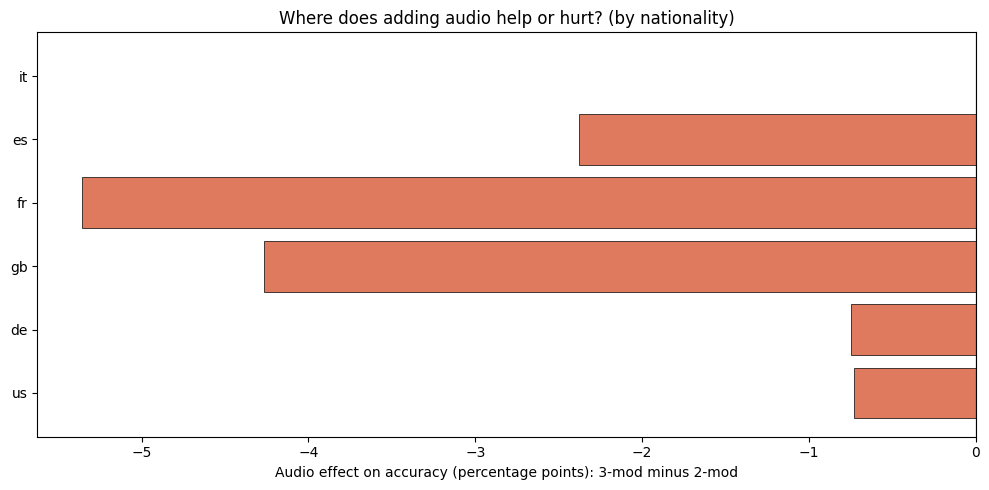

In [13]:
# Same idea, grouped by the anchor's nationality.

nat_2mod = per_group_accuracy(lookups["2-mod (image+caption)"], lambda u: str(uuid_nationality(u)))
nat_3mod = per_group_accuracy(lookups["3-mod (full)"],          lambda u: str(uuid_nationality(u)))

nat_cmp = nat_2mod.merge(nat_3mod, on="group", suffixes=("_2mod", "_3mod"))
nat_cmp["audio_effect"] = nat_cmp["accuracy_3mod"] - nat_cmp["accuracy_2mod"]
nat_cmp = nat_cmp.sort_values("n_2mod", ascending=False)

print("Per-nationality test accuracy: 2-mod vs 3-mod\n")
print(nat_cmp[["group", "n_2mod", "accuracy_2mod", "accuracy_3mod", "audio_effect"]].to_string(index=False))

if len(nat_cmp) >= 2:
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#3d5a80" if e >= 0 else "#e07a5f" for e in nat_cmp["audio_effect"]]
    ax.barh(nat_cmp["group"], nat_cmp["audio_effect"] * 100, color=colors, edgecolor="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Audio effect on accuracy (percentage points): 3-mod minus 2-mod")
    ax.set_title("Where does adding audio help or hurt? (by nationality)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "audio_effect_by_nationality.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("\n(Too few nationality groups above the min_count threshold to plot.)")

In [14]:
# Part A: Qualitative top-10 similar artists, 2-mod vs 3-mod, for several queries.

def top_k_similar(lookup, query_name, k=10):
    q = name_to_uuid.get(query_name)
    if q is None or q not in lookup:
        return None
    qv = lookup[q]
    sims = [(u, float(qv @ lookup[u])) for u in lookup if u != q]
    sims.sort(key=lambda x: x[1], reverse=True)
    return [(uuid_name(u), uuid_genre(u), s) for u, s in sims[:k]]

QUERIES = ["DJ Shadow", "Metallica", "Alabama Shakes", "Hans Zimmer", "Chick Corea",
           "Daft Punk", "Radiohead", "Miles Davis"]

for q in QUERIES:
    print("=" * 90)
    print(f"QUERY: {q}")
    print("=" * 90)
    for label in ["2-mod (image+caption)", "3-mod (full)"]:
        res = top_k_similar(lookups[label], q, k=10)
        print(f"\n[{label}]")
        if res is None:
            print("  (not in pool)")
        else:
            for i, (name, genre, s) in enumerate(res, 1):
                print(f"  {i:2d}. {s:.3f}  {name:32s} ({genre})")
    print()


# Part B: Failure analysis — test triplets the 3-mod gets WRONG but the 2-mod gets RIGHT.
print("\n" + "=" * 90)
print("FAILURE ANALYSIS: triplets where adding audio BROKE a correct 2-mod prediction")
print("=" * 90)

lk2 = lookups["2-mod (image+caption)"]
lk3 = lookups["3-mod (full)"]

regressions = []
for a, p, n in test_triplets:
    ok2 = triplet_correct(lk2, a, p, n)
    ok3 = triplet_correct(lk3, a, p, n)
    if ok2 and not ok3:   # 2-mod right, 3-mod wrong = audio broke it
        regressions.append((a, p, n))

print(f"\nTotal regressions (2-mod correct, 3-mod wrong): {len(regressions)} "
      f"out of {len(test_triplets)} test triplets\n")

# Show the first 15 with names and genres
for a, p, n in regressions[:15]:
    print(f"  anchor:   {uuid_name(a):28s} ({uuid_genre(a)})")
    print(f"  positive: {uuid_name(p):28s} ({uuid_genre(p)})")
    print(f"  negative: {uuid_name(n):28s} ({uuid_genre(n)})")
    print()

QUERY: DJ Shadow

[2-mod (image+caption)]
   1. 0.832  Yppah                            (fusion)
   2. 0.815  Ruby Ibarra                      (hip hop)
   3. 0.804  Odd Nosdam                       (hip hop)
   4. 0.802  Floating Points                  (dance)
   5. 0.800  Daniel Avery                     (pop)
   6. 0.793  Scuba                            (classic)
   7. 0.783  Machinedrum                      (hip hop)
   8. 0.775  Baauer                           (house)
   9. 0.762  The Cinematic Orchestra          (jazz)
  10. 0.761  Color Theory                     (nan)

[3-mod (full)]
   1. 0.872  Flying Lotus                     (hip hop)
   2. 0.864  Joker                            (classic)
   3. 0.862  Baauer                           (house)
   4. 0.856  Hudson Mohawke                   (hip hop)
   5. 0.856  Com Truise                       (nan)
   6. 0.854  Onra                             (hip hop)
   7. 0.852  Beacon                           (pop)
   8. 0.835  Zoo